<a href="https://colab.research.google.com/github/ak07888/AI-MARKET-ANALYSIS-/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fear = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print("Fear Dataset Shape:", fear.shape)
print("Trades Dataset Shape:", trades.shape)

Fear Dataset Shape: (2644, 4)
Trades Dataset Shape: (32550, 16)


In [ ]:
print(fear.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [ ]:
for col in trades.columns:
    print(col)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp


In [ ]:
print("Fear & Greed Missing Values")
print(fear.isnull().sum())

print("\nTrader Missing Values")
print(trades.isnull().sum())

print("\nFear Duplicates:", fear.duplicated().sum())
print("Trade Duplicates:", trades.duplicated().sum())

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64

Fear Duplicates: 0
Trade Duplicates: 0


In [ ]:
fear['date'] = pd.to_datetime(fear['date'])

trades['trade_date'] = pd.to_datetime(
    trades['Timestamp IST'], format="%d-%m-%Y %H:%M"
)

In [ ]:
daily_metrics = trades.groupby(
    'trade_date'
).agg(
    daily_pnl=('Closed PnL','sum'),
    total_trades=('Account','count'),
    avg_trade_size=('Size USD','mean'),
    total_volume=('Size USD','sum')
).reset_index()

daily_metrics.head()

,trade_date,daily_pnl,total_trades,avg_trade_size,total_volume
0,2024-01-19 06:47:00,-0.040,2,246.6200,493.24
1,2024-01-19 07:45:00,0.000,1,24.6200,24.62
2,2024-01-19 07:57:00,-0.167,4,239.7775,959.11
3,2024-01-19 16:37:00,0.000,1,24.9200,24.92
4,2024-01-19 16:38:00,0.003,1,24.9200,24.92


In [ ]:
trades['win'] = np.where(
    trades['Closed PnL'] > 0,
    1,
    0
)

win_rate = trades.groupby(
    'trade_date'
)['win'].mean().reset_index()

win_rate.rename(
    columns={'win':'win_rate'},
    inplace=True
)

daily_metrics = daily_metrics.merge(
    win_rate,
    on='trade_date'
)

In [ ]:
merged = daily_metrics.merge(
    fear[['date','classification']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

merged.head()

,trade_date,daily_pnl,total_trades,avg_trade_size,total_volume,win_rate_x,win_rate_y,win_rate,date,classification
0,2024-01-19 06:47:00,-0.040,2,246.6200,493.24,0.0,0.0,0.0,NaT,NaN
1,2024-01-19 07:45:00,0.000,1,24.6200,24.62,0.0,0.0,0.0,NaT,NaN
2,2024-01-19 07:57:00,-0.167,4,239.7775,959.11,0.0,0.0,0.0,NaT,NaN
3,2024-01-19 16:37:00,0.000,1,24.9200,24.92,0.0,0.0,0.0,NaT,NaN
4,2024-01-19 16:38:00,0.003,1,24.9200,24.92,1.0,1.0,1.0,NaT,NaN


In [ ]:
comparison = merged.groupby(
    'classification'
).agg(
    avg_pnl=('daily_pnl','mean'),
    avg_win_rate=('win_rate','mean'),
    avg_trades=('total_trades','mean'),
    avg_volume=('total_volume','mean')
)

print(comparison)

                   avg_pnl  avg_win_rate  avg_trades  avg_volume
classification                                                  
Extreme Greed   102.018843           0.5         3.0    38701.31
Greed             0.000000           0.0         5.0    55973.62
Neutral           0.000000           0.0         1.0    19999.74


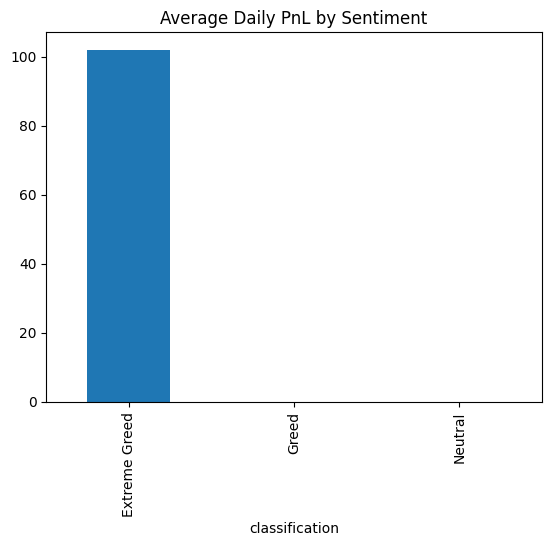

In [ ]:
comparison['avg_pnl'].plot(
    kind='bar'
)

plt.title('Average Daily PnL by Sentiment')
plt.show()

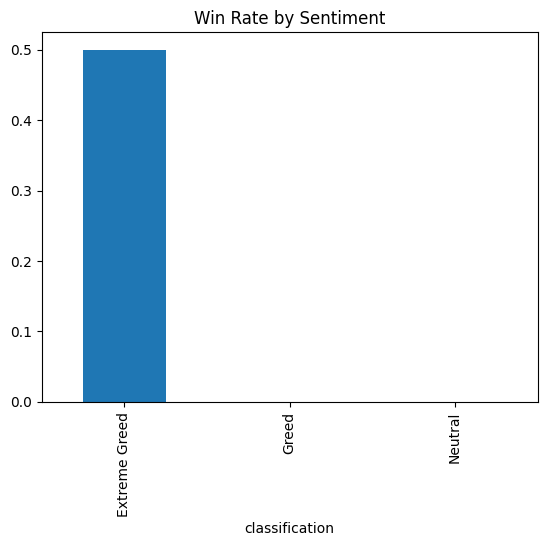

In [ ]:
comparison['avg_win_rate'].plot(
    kind='bar'
)

plt.title('Win Rate by Sentiment')
plt.show()

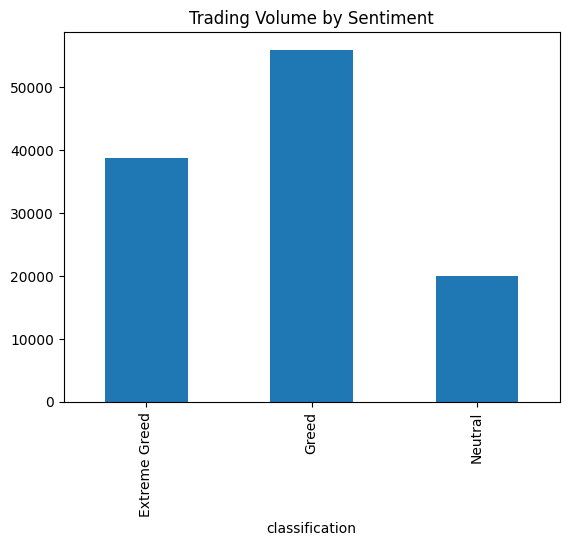

In [ ]:
comparison['avg_volume'].plot(
    kind='bar'
)

plt.title('Trading Volume by Sentiment')
plt.show()

In [ ]:
activity = trades.groupby(
    'Account'
).size().reset_index(name='trade_count')

median_count = activity['trade_count'].median()

activity['segment'] = np.where(
    activity['trade_count'] >= median_count,
    'Frequent',
    'Infrequent'
)

print(activity['segment'].value_counts())

segment
Frequent      4
Infrequent    4
Name: count, dtype: int64


In [ ]:
trader_pnl = trades.groupby(
    'Account'
)['Closed PnL'].sum().reset_index()

trader_pnl['segment'] = np.where(
    trader_pnl['Closed PnL'] > 0,
    'Winner',
    'Loser'
)

print(trader_pnl['segment'].value_counts())

segment
Winner    8
Name: count, dtype: int64
